# Name: Fereshteh Sadeghi Naieni Fard

# PART V: Build, Train, Test, and Evaluate ML Models

## 1. Load the Dataset

#### 1.1. Import Essential Libraries and Modules 

In [76]:
#Import pandas and numpy libraries
import pandas as pd
import numpy as np

#Import Visulaization libraries and modules
from pandas.plotting import scatter_matrix
from matplotlib import pyplot

#Import Scikit learn module for the algorithm/model: Kmeans
from sklearn.cluster import KMeans

The dataset car_evaluation.csv was collected with the following attributes:  
1.Price: Buying price  
2.Maintenance: Maintenance cost  
3.Doors: Number of doors  
4.Passengers: Number of passengers  
5.Luggage: Size of luggage boot  
6.Safety: Estimated safety of the car  
7.Evaluation: Evaluation of the car  

In [77]:
#Avoid warnings
import warnings
warnings.filterwarnings('ignore')

#### 2. Load the Dataset

In [78]:
# Specify the filename and path 
filename='C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/car_evaluation.csv'

#Determine names of the fields
names=['Price','Maintenance','Doors','Passengers','Luggage','Safety','Evaluation']

# Insert data into a Pandas Dataframe 
df=pd.read_csv(filename,names=names, index_col= False)


## 2. Preprocess the Dataset

In [79]:
#Class distribution for price
#Means how many records for each class 
print(df.groupby('Price').size())

Price
high     432
low      432
med      432
vhigh    432
dtype: int64


In [80]:
#Class distribution for maintanance
#Means how many records for each class 
print(df.groupby('Maintenance').size())

Maintenance
high     432
low      432
med      432
vhigh    432
dtype: int64


In [81]:
#Class distribution for doors
#Means how many records for each class 
print(df.groupby('Doors').size())

Doors
2        432
3        432
4        432
5more    432
dtype: int64


In [82]:
#Class distribution for passangers
#Means how many records for each class 
print(df.groupby('Passengers').size())

Passengers
2       576
4       576
more    576
dtype: int64


In [83]:
#Class distribution for luggage size
#Means how many records for each class 
print(df.groupby('Luggage').size())

Luggage
big      576
med      576
small    576
dtype: int64


In [84]:
#Class distribution for level of safety
#Means how many records for each class 
print(df.groupby('Safety').size())

Safety
high    576
low     576
med     576
dtype: int64


In [85]:
#Class distribution for evaluation level
#Means how many records for each class 
print(df.groupby('Evaluation').size())

Evaluation
acc       384
good       69
unacc    1210
vgood      65
dtype: int64


#### Comments on the Dataset:
In the Doors Field, some records have 5more values and they should be modified to 5  
In Passengers Field, some records have more values and they should be modified to 5  

In [86]:
#Replace 5more with 5 in Doors field
df['Doors']=df['Doors'].replace('5more',5)

In [87]:
# Replace more with 5 in passangers field
df['Passengers']=df['Passengers'].replace('more',5)

In [88]:
# Turn these two field into numeric ones
df['Doors'] = pd.to_numeric(df['Doors'], errors='coerce')
df['Passengers'] = pd.to_numeric(df['Passengers'], errors='coerce')

In [89]:
#print number of null records in each field
print(df.isnull().sum())

Price          0
Maintenance    0
Doors          0
Passengers     0
Luggage        0
Safety         0
Evaluation     0
dtype: int64


In [90]:
df.to_csv('C:/unt courses/Ph.D courses/INFO-ADTA 5340-Discovery and Learning with Big Data/Week8 Final Project/car_evaluation_clean.csv',index=False)

## 3. Perform Exploratory Data Analysis

In [15]:
#Get the dimensions or shape of the dataset
print(df.shape)

(1728, 7)


In [16]:
#Get the data types of all the attributes
print(df.dtypes)

Price          object
Maintenance    object
Doors           int64
Passengers      int64
Luggage        object
Safety         object
Evaluation     object
dtype: object


In [22]:
#Get the data types of all the varaibles of the dataset
df.head(5)

,Price,Maintenance,Doors,Passengers,Luggage,Safety,Evaluation
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [17]:
#Get the summary statistics of the numeric variables of the dataset
print(df.describe())

             Doors   Passengers
count  1728.000000  1728.000000
mean      3.500000     3.666667
std       1.118358     1.247580
min       2.000000     2.000000
25%       2.750000     2.000000
50%       3.500000     4.000000
75%       4.250000     5.000000
max       5.000000     5.000000


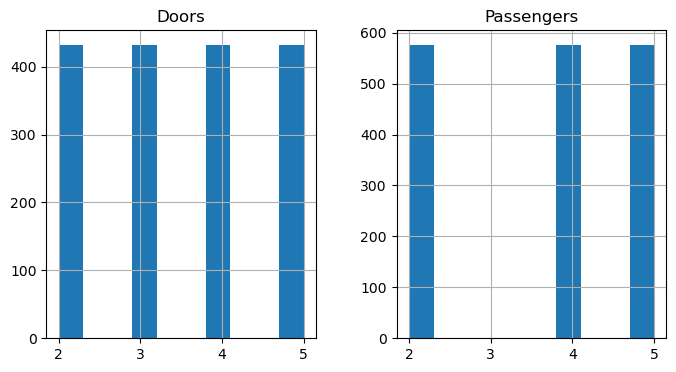

In [18]:
#Plot histogram for each numeric variable of the dataset
df.hist(figsize=(8,4))
pyplot.show()

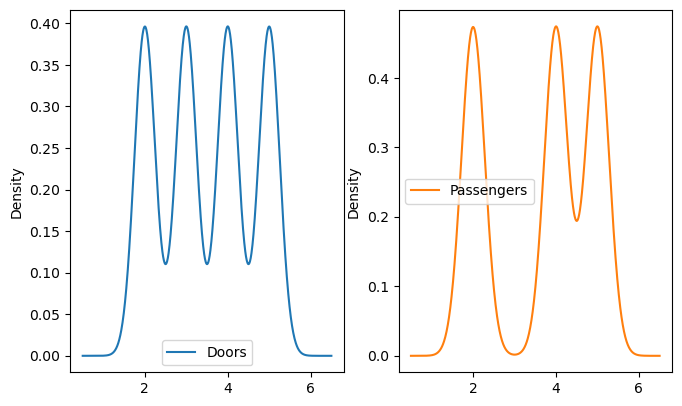

In [19]:
#Plot density plots for each numeric variable of the dataset
df.plot(kind='density', subplots=True,sharex=False, layout=(3,3), legend=True, figsize=(12,16))
pyplot.show()

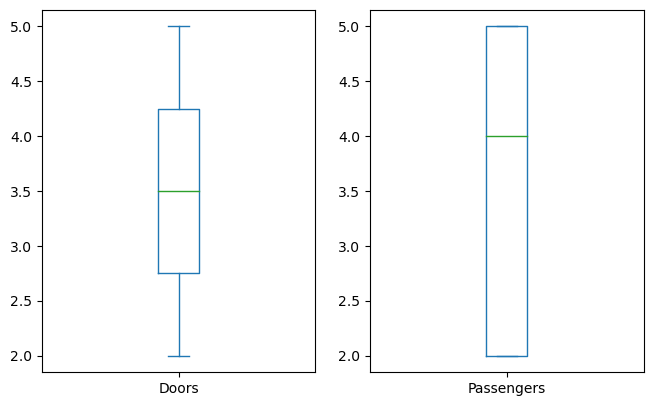

In [20]:
#Plot Boxplots for each numeric variable of the dataset
df.plot(kind='box', subplots=True,sharex=False, sharey=False, layout=(3,3), legend=True, figsize=(12,16))
pyplot.show()

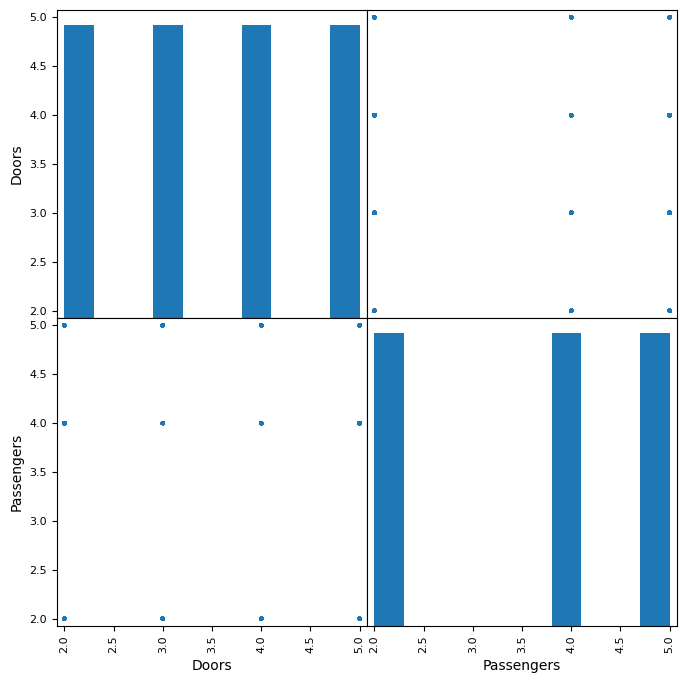

In [21]:
#Scatter plot matrix
scatter_matrix(df, alpha=0.8, figsize=(8,8))
pyplot.show()

# Question: Should we exclude Evaluation from the features?

## 4. Split the Dataset into Input and Output

In [23]:
#Convert category labels to numeric labales by setting the predefined orders for price
df['Price'] = df['Price'].str.strip()
df['Price'] = pd.Categorical(df['Price'], categories=['low','med', 'high','vhigh'], ordered=True)
df['Price'] = df['Price'].cat.codes  # 'low'=0,'med'=1, 'high'=2,'vhigh'=3


In [24]:
#Convert category labels to numeric labales by setting the predefined orders for maintanance
df['Maintenance'] = df['Maintenance'].str.strip()
df['Maintenance'] = pd.Categorical(df['Maintenance'], categories=['low','med', 'high','vhigh'], ordered=True)
df['Maintenance'] = df['Maintenance'].cat.codes  # 'low'=0,'med'=1, 'high'=2,'vhigh'=3

In [25]:
#Convert category labels to numeric labales by setting the predefined orders for luggage size
df['Luggage'] = df['Luggage'].str.strip()
df['Luggage'] = pd.Categorical(df['Luggage'], categories=['small', 'med', 'big'], ordered=True)
df['Luggage'] = df['Luggage'].cat.codes  # small=0, med=1,  big=2

In [26]:
#Convert category labels to numeric labales by setting the predefined orders for safety level
df['Safety'] = df['Safety'].str.strip()
df['Safety'] = pd.Categorical(df['Safety'], categories=['low','med', 'high'], ordered=True)
df['Safety'] = df['Safety'].cat.codes  # 'low'=0,'med'=1, 'high'=2

In [27]:
#Insert the datasfram into a numpy array
array=df.values

#Specify the variables that we use for clustering
x=array[:,:6]


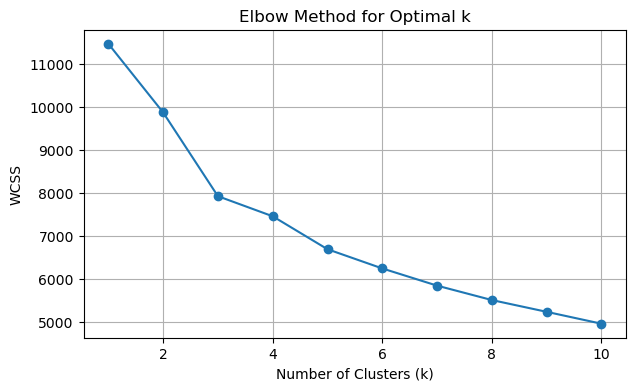

In [56]:
#Uisng Elbow method to find the optimum number of clusters
wcss = []  # Within-Cluster-Sum-of-Squares

# Try cluster numbers from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=7)
    kmeans.fit(x)       # x = your clustering data
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
pyplot.figure(figsize=(7,4))
pyplot.plot(range(1, 11), wcss, marker='o')
pyplot.title('Elbow Method for Optimal k')
pyplot.xlabel('Number of Clusters (k)')
pyplot.ylabel('WCSS')
pyplot.grid(True)
pyplot.show()


## 5. Build the Model

In [57]:
#Build the model
model=KMeans(n_clusters=3)

In [58]:
#Use the model to cluster the input data with 3 clusters
model.fit(x)

KMeans(n_clusters=3)

In [59]:
#print the centroid vectors
centroids=model.cluster_centers_
print(centroids)

[[1.90625 1.90625 4.21875 4.5     1.      1.     ]
 [1.09375 1.09375 2.78125 4.5     1.      1.     ]
 [1.5     1.5     3.5     2.      1.      1.     ]]


In [60]:
#Takes the cluster labels produced by a clustering model and prints only every 10th label
cluster_labels=model.labels_[::10]
print(cluster_labels)

[2 0 0 2 0 0 2 0 0 0 0 2 1 1 2 0 0 2 0 2 0 0 2 1 1 2 0 2 0 0 2 0 0 2 1 1 1
 1 2 0 0 2 0 0 2 1 2 0 0 2 0 0 2 0 2 1 1 2 0 0 2 0 0 0 0 2 1 1 2 1 1 2 0 2
 0 0 2 1 1 2 1 2 1 1 2 0 0 2 1 1 0 0 2 0 0 2 0 0 2 1 2 1 1 2 0 0 2 0 2 1 1
 2 1 1 2 1 1 0 0 2 1 1 2 1 1 2 1 2 0 0 2 1 1 2 1 2 0 0 2 0 0 2 1 1 1 1 2 1
 1 2 0 0 2 1 2 1 1 2 1 1 2 0 2 1 1 2 1 1 2 1 1 1 1]


In [70]:
cluster_labels=model.labels_

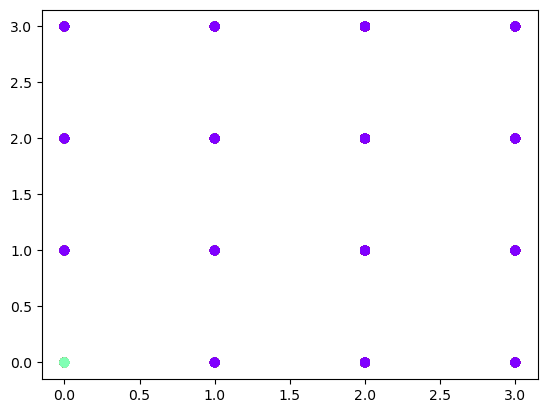

In [71]:
# Plot the scatter plot of the first two dimesnion of the predictors 
pyplot.scatter(x[:,0],x[:,1],c=model.labels_,cmap='rainbow')
pyplot.show()

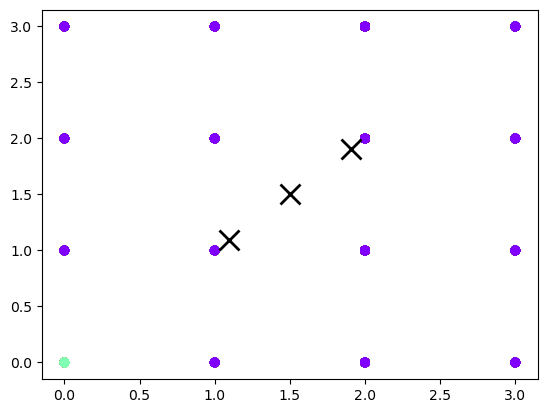

In [72]:
#Plot the datapoints with centroids
pyplot.scatter(x[:,0],x[:,1],c=model.labels_, cmap='rainbow')

lines=pyplot.plot(centroids[0,0],centroids[0,1],'kx')
pyplot.setp(lines,ms=15.0)
pyplot.setp(lines,mew=2.0)

lines=pyplot.plot(centroids[1,0],centroids[1,1],'kx')
pyplot.setp(lines,ms=15.0)
pyplot.setp(lines,mew=2.0)

lines=pyplot.plot(centroids[2,0],centroids[2,1], 'kx')
pyplot.setp(lines,ms=15.0)
pyplot.setp(lines, mew=2.0)

pyplot.show()

## 7. Train the Model

## 8. Prediction

Prediction1:  
1.Price:med=1   
2.Maintenance: low =0   
3.Doors: 4    
4.Passengers: 5     
5.Luggage: small=0   
6.Safety: med=1   

In [36]:
model.predict([[1,0,4,5,0,1]])

array([1])

Prediction2:    
1.Price:high=2    
2.Maintenance: Vhigh =3   
3.Doors: 5   
4.Passengers: 5    
5.Luggage: big=2   
6.Safety: high=2  

In [68]:
model.predict([[2,3,5,5,2,2]])

array([0])